<a href="https://colab.research.google.com/github/JanPelisek/dostupnost-JMK/blob/main/rozpracovane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Manažerské shrnutí**

- doplnit texty

**Příprava prostředí**

In [83]:
!pip install osmnx r5py geopandas matplotlib pandas shapely folium osm2geojson mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.2 MB/s eta 0:00:00


In [60]:
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import osm2geojson
import pandas as pd
import r5py
from shapely.geometry import Polygon, shape
import folium
import requests
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


**Geografické vymezení úlohy**



Načtení hranic Jihomoravského kraje a jednotlivých okresů

*   Položka seznamu
*   Položka seznamu




In [29]:
# API pro ADM2 v ČR (okresy).
api_url_okr = "https://www.geoboundaries.org/api/current/gbOpen/CZE/ADM2"
hranice_okr = requests.get(api_url)
len(hranice_okr.json())

# Všechny okresy ČR, kontrola názvů
okresy = gpd.read_file(hranice_okr.json()['gjDownloadURL'])
display(okresy.head())
print(okresy["shapeName"].unique())

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Nový Jičín,,57006924B81305487356227,CZE,ADM2,"POLYGON ((18.04966 49.80866, 18.04867 49.80073..."
1,Cheb,,57006924B74936445485800,CZE,ADM2,"POLYGON ((12.38127 50.28779, 12.37307 50.28735..."
2,Sokolov,,57006924B20358302460191,CZE,ADM2,"POLYGON ((12.82103 50.04788, 12.82059 50.05541..."
3,Karlovy Vary,,57006924B50757157558324,CZE,ADM2,"POLYGON ((12.9561 49.9789, 12.95588 49.98081, ..."
4,Chomutov,,57006924B32669310027153,CZE,ADM2,"POLYGON ((13.25622 50.23573, 13.25958 50.23615..."


['Nový Jičín' 'Cheb' 'Sokolov' 'Karlovy Vary' 'Chomutov' 'Most' 'Teplice'
 'Ústí nad Labem' 'Děčín' 'Louny' 'Litoměřice' 'Česká Lípa' 'Liberec'
 'Jablonec nad Nisou' 'Semily' 'Trutnov' 'Náchod' 'Tachov' 'Domažlice'
 'Plzeň-North' 'Rakovnik' 'Klatovy' 'Plzeň-South' 'Plzeň-City' 'Rokycany'
 'Kladno' 'Mělník' 'Mladá Boleslav' 'Jičín' 'Hradec Králové'
 'Rychnov nad Kněžnou' 'Pardubice' 'Chrudim' 'Ústí nad Orlicí' 'Jeseník'
 'Nymburk' 'Kolín' 'Beroun' 'Prague-East' 'Prague' 'Prague-West' 'Benešov'
 'Příbram' 'Kutná Hora' 'České Budějovice' 'Písek' 'Prachatice'
 'Strakonice' 'Český Krumlov' 'Jindřichův Hradec' 'Tábor' 'Třebíč'
 'Pelhřimov' 'Havlíčkův Brod' 'Žďár nad Sázavou' 'Jihlava' 'Vsetín'
 'Uherské Hradiště' 'Kroměříž' 'Zlín' 'Brno-Country' 'Svitavy' 'Hodonín'
 'Znojmo' 'Břeclav' 'Blansko' 'Vyškov' 'Brno-City' 'Prostějov' 'Přerov'
 'Olomouc' 'Bruntál' 'Šumperk' 'Opava' 'Karviná' 'Frýdek-Místek'
 'Ostrava-City']


In [32]:
jhm_okresy = ['Hodonín','Brno-Country','Znojmo', 'Břeclav', 'Blansko', 'Vyškov', 'Brno-City']
jhm_okresy_gdf = okresy[okresy["shapeName"].isin(jhm_okresy)]
len(jhm_okresy_gdf) # 7 okresů

7

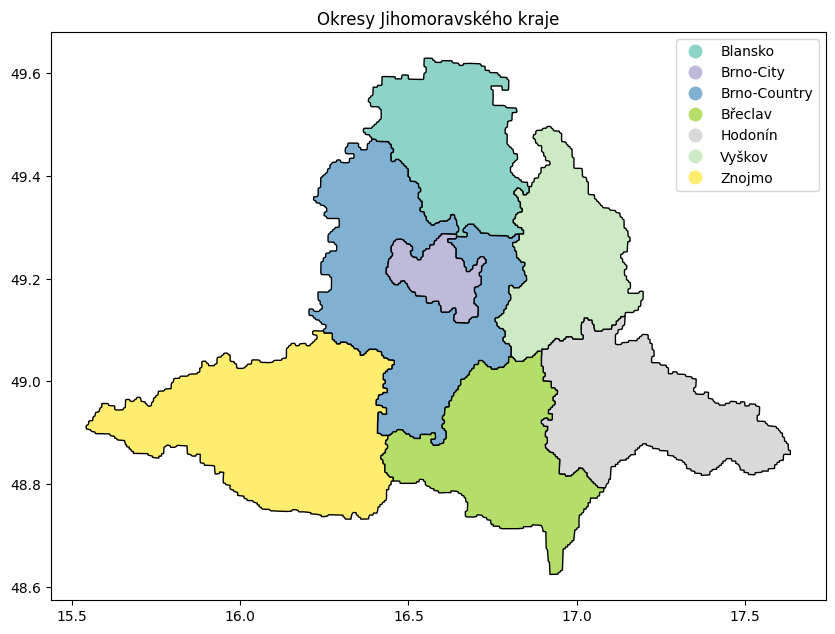

In [33]:
fig, ax = plt.subplots(figsize=(10,10))
jhm_okresy_gdf.plot(ax=ax, column="shapeName", cmap="Set3", legend=True, edgecolor='black')
ax.set_title("Okresy Jihomoravského kraje")
plt.show()

Filtr Brno-střed, počet záznamů: 1
       kod       nazev             datum_exportu  ObjectId   Shape__Area  \
15  550973  Brno-střed 2024-09-14 00:00:00+00:00        16  3.425288e+07   

    Shape__Length                                           geometry  
15   32238.997112  POLYGON ((16.59367 49.21105, 16.59369 49.21099...  


<ipython-input-79-52c5664e1273>:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
<ipython-input-79-52c5664e1273>:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


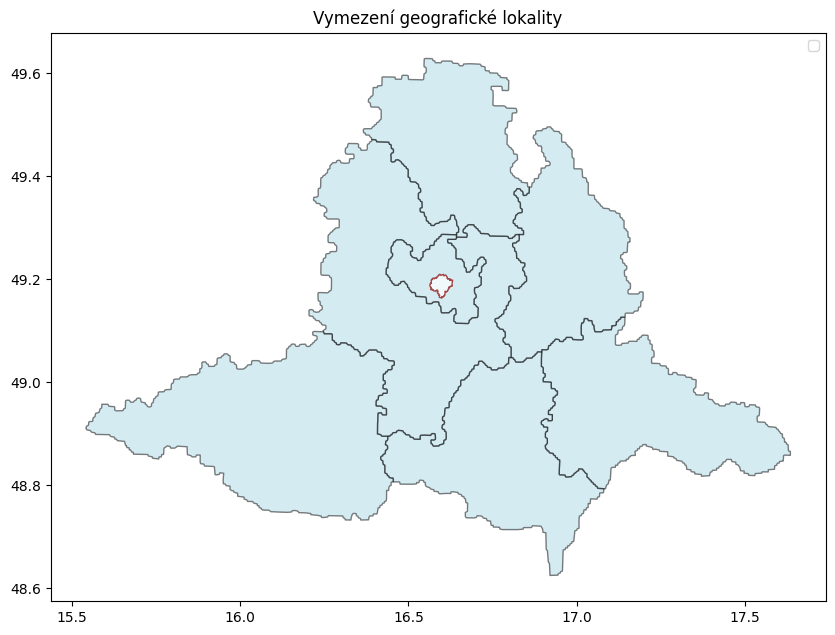

In [79]:
mestske_casti = gpd.read_file("https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/m_casti_brno.geojson")

# 3) Filtrace pro Brno-střed
brno_stred = mestske_casti[mestske_casti["nazev"] == "Brno-střed"]

print("Filtr Brno-střed, počet záznamů:", len(brno_stred))
print(brno_stred.head())

# 4) Kontrola a případná transformace do stejného CRS jako 'jhm_okresy_gdf'
#    Pokud jhm_okresy_gdf má jiný CRS, např. EPSG:5514 a brno_stred EPSG:4326, je třeba sjednotit.
if brno_stred.crs != jhm_okresy_gdf.crs:
    brno_stred = brno_stred.to_crs(jhm_okresy_gdf.crs)

# 5) Vykreslení - okresy a do nich polygon Brno-střed
fig, ax = plt.subplots(figsize=(10, 8))
jhm_okresy_gdf.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="Okresy Jihomoravského kraje")
brno_stred.plot(ax=ax, color="white", edgecolor="darkred", alpha=0.7, label="Brno-střed")
ax.set_title("Vymezení geografické lokality s cílovou destinací Brno-střed")
plt.legend()
plt.show()